# Part 1: Analyzing the Steady-State Behavior of a sine-driven LRC Circuit

We use https://www.falstad.com/circuit/ to simulate our built circuits to ensure we are measuring what we expect. To measure out L, C, and R, we are using a handeld LCR Meter found at [1]. The datasheet for this meter is found at [2]. Additionaly, we are using a signal generator found at [3] to generate our driving voltage.

[1] **(Type of LCR Meter)**
https://www.axiomtest.com/Component-Analyzers,-LCR,-Semiconductor/Impedance,-Capacitance-and-LCR/Keysight-..-Agilent/U1733C/100kHz-Handheld-LCR-Meter/?msclkid=db169271c99f16ec5ebbfbd95ba32e4b&utm_source=bing&utm_medium=cpc&utm_campaign=Rent%20Test%20Equipment%20B&utm_term=axiomtest&utm_content=Dynamic%20Ad%20-%20Rent%20Test%20Equip%20B

[2] **(LCR Meter Data Sheet)**
https://www.axiomtest.com/documents/models/KT%20U1733C%20Datasheet.pdf

[3] **(Type of Signal Generator)**
https://www.koolertron.com/koolertron-dds-signal-generator-counter-2-8-inch-screen-display-60mhz-high-precision-dual-channel-arbitrary-waveform-generator-frequency-counter-275-msa-s-can-be-controlled-by-mobile-phone.html


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from helper import *

In [12]:
# Measured values we keep constant in our circuit
L = 11.248e-3 # Farads
C = 1.438e-9 # Henries
omega_0 = calculate_omega_0(L, C)
# Calculate natural frequency of the system (Why doesn't this depend on resistance?)
print(f"Freq_0:  {omega_0 / (2 * np.pi):.2f} Hz")

Freq_0:  39573.37 Hz


## R = $470 \Omega$ Resistor

In [3]:
# Import Data

omega_data = []
voltage_ratio_data = []

In [ ]:
# Insert measured values for R, L, and C
R = 463.1 # Ohms
Rtotal = 485.33 # R + impedance from inductor (don't include R from the scope! ?)
# Rtotal = 535.33 if include R from scope

gamma = calculate_gamma(Rtotal, L)
omega_res = calculate_omega_res(Rtotal, L, C)

# print(f"Gamma: {gamma:.2f}")
print(f"Freq_0:  {omega_0 / (2 * np.pi):.2f}")
print(f"Freq res:  {omega_res / (2 * np.pi):.2f}")

Freq_0:  39573.37
Freq res:  39274.32


In [5]:
print(f"Uncertainty: +/- {calculate_inductance_uncertainty_1khz(L, False):.2e} Farads")
print(f"Uncertainty: +/- {calculate_resistance_uncertainty_1khz(R):.2e} Ohms")
print(f"Uncertainty: +/- {calculate_capacitance_uncertainty_1khz(C):.2e} Henries")

Uncertainty: +/- 2.55e-05 Farads
Uncertainty: +/- 1.23e+00 Ohms
Uncertainty: +/- 3.18e-12 Henries


In [6]:
# Calculate bounds of freq_0 and freq_res based on the uncertainties
results = calculate_frequency_bounds(Rtotal, L, C)

--- Frequency Uncertainty Analysis ---
Freq_0  : (3.957 +/- 0.009)e04 Hz
   [Range: 39485.02 to 39662.12 Hz]

Freq_res: (3.927 +/- 0.009)e04 Hz
   [Range: 39185.08 to 39363.96 Hz]



<>:16: SyntaxWarning: invalid escape sequence '\O'
<>:16: SyntaxWarning: invalid escape sequence '\O'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_59874/48595801.py:16: SyntaxWarning: invalid escape sequence '\O'
  label=f'Expected curve for \n$R={R:.2f} \Omega$, \n$C={C:.2f}nH$, \n$L={L:.2f}mF$, \n$Freq ={freq_0:.0f} Hz$')


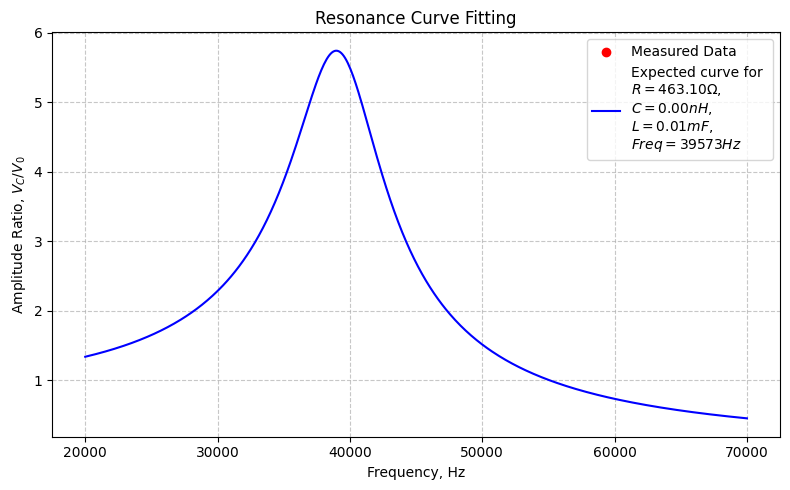

In [7]:
plt.figure(figsize=(8, 5))

# Plot raw data
plt.scatter(omega_data, voltage_ratio_data, color='red', label='Measured Data', zorder=3)

# Plot smooth curve
# omega_smooth = np.linspace(min(omega_data), max(omega_data), 500)
omega_smooth = np.linspace(20000, 70000, 500)
fitted_curve = resonance_curve(omega_smooth * (2*np.pi), gamma, omega_res)

# Calculate freq_0
freq_0 = omega_0 / (2 * np.pi)

# Plot the fitted curve
plt.plot(omega_smooth, fitted_curve, color='blue', 
         label=f'Expected curve for \n$R={R:.2f} \Omega$, \n$C={C:.2f}nH$, \n$L={L:.2f}mF$, \n$Freq ={freq_0:.0f} Hz$')

# Formatting the plot
plt.title('Resonance Curve Fitting')
plt.xlabel(r'Frequency, Hz')
plt.ylabel(r'Amplitude Ratio, $V_C / V_0$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()

## Fit Gathered Data

## R = $470 \Omega$ Resistor

## R = $470 \Omega$ Resistor